
--------------------------------------
Differential Equation → Control System
--------------------------------------

INPUT FORMAT EXAMPLES

2*D**2*y + D*y + y = x
2*D**2*y + D*y = D*x + x
D**3*y + 5*D*y + 2*y = x
4*D**2*y + 7*y = 3*x


Laplace Equation:
2*Y*s**2 + Y*s = X*s + X

Transfer Function G(s) = Y(s)/X(s):

   s + 1   
───────────
s⋅(2⋅s + 1)

Transfer Function (control library):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s

Generating plots...



C:\Users\erinx\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\lti.py:646: FutureWarning: freqresp() is deprecated; use frequency_response()
  warn("freqresp() is deprecated; use frequency_response()", FutureWarning)


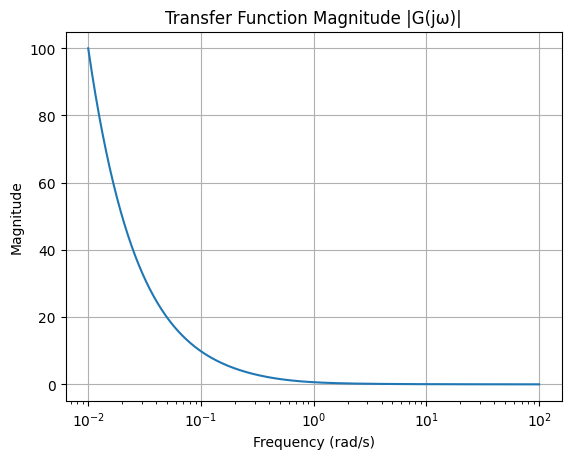

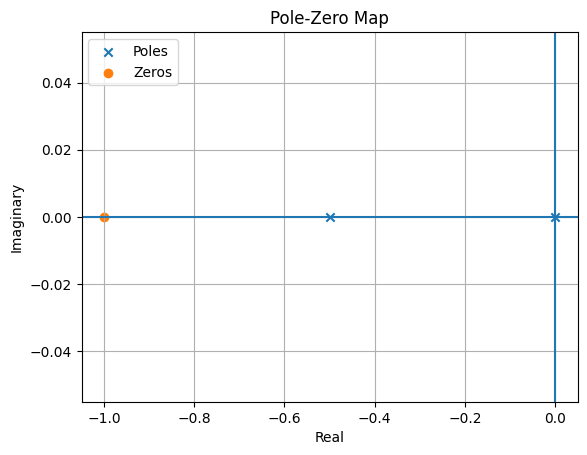


Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


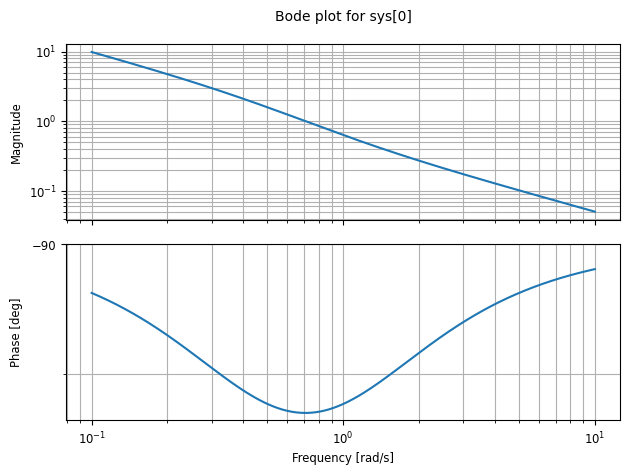

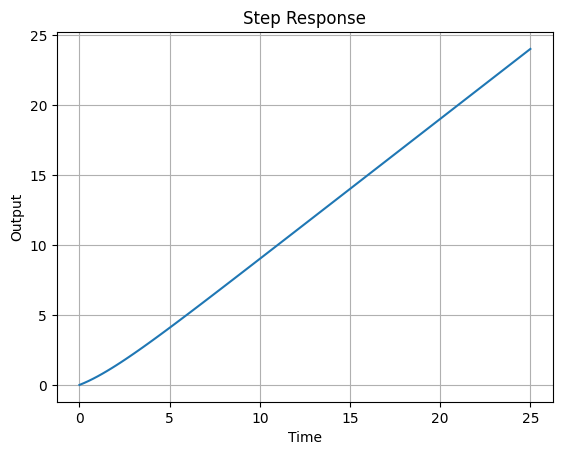

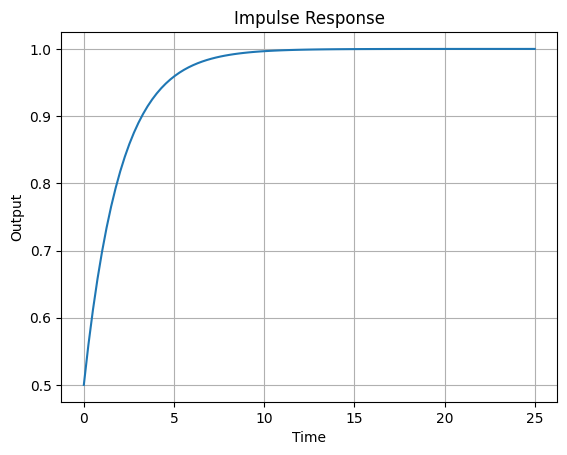

In [ ]:

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import control
import re


# --------------------------------------------------
# SYMBOLIC VARIABLES
# --------------------------------------------------

s = sp.symbols('s')
Y = sp.symbols('Y')
X = sp.symbols('X')


# --------------------------------------------------
# NORMALIZE INPUT
# --------------------------------------------------

def normalize_equation(eq):

    eq = eq.replace(" ", "")
    eq = eq.lower()

    return eq


# --------------------------------------------------
# PARSE DIFFERENTIAL EQUATION
# --------------------------------------------------

def parse_equation(eq):

    eq = normalize_equation(eq)

    try:
        left, right = eq.split("=")
    except:
        raise ValueError("Equation must contain '='")

    # Convert derivatives of y
    for i in range(10,0,-1):

        left = re.sub(rf"d\*\*{i}\*y", f"s**{i}*Y", left)
        right = re.sub(rf"d\*\*{i}\*y", f"s**{i}*Y", right)

    left = left.replace("d*y", "s*Y")
    right = right.replace("d*y", "s*Y")

    # Convert derivatives of x
    for i in range(10,0,-1):

        left = re.sub(rf"d\*\*{i}\*x", f"s**{i}*X", left)
        right = re.sub(rf"d\*\*{i}\*x", f"s**{i}*X", right)

    left = left.replace("d*x", "s*X")
    right = right.replace("d*x", "s*X")

    # Replace plain variables
    left = left.replace("y", "Y")
    right = right.replace("x", "X")

    left_expr = sp.sympify(left)
    right_expr = sp.sympify(right)

    return left_expr, right_expr


# --------------------------------------------------
# COMPUTE TRANSFER FUNCTION
# --------------------------------------------------

def compute_transfer_function(left, right):

    equation = sp.Eq(left, right)

    solution = sp.solve(equation, Y)

    if len(solution) == 0:
        raise ValueError("Cannot solve equation")

    Y_expr = solution[0]

    G = sp.simplify(Y_expr / X)

    return G


# --------------------------------------------------
# CONVERT SYMPY TF → CONTROL TF
# --------------------------------------------------

def sympy_to_control(G):

    num, den = sp.fraction(G)

    num_poly = sp.Poly(num, s)
    den_poly = sp.Poly(den, s)

    num_coeff = [float(c) for c in num_poly.all_coeffs()]
    den_coeff = [float(c) for c in den_poly.all_coeffs()]

    sys = control.TransferFunction(num_coeff, den_coeff)

    return sys


# --------------------------------------------------
# TRANSFER FUNCTION GRAPH
# --------------------------------------------------

def plot_transfer_function(sys):

    w = np.logspace(-2,2,500)

    mag, phase, omega = control.freqresp(sys, w)

    mag = mag.flatten()

    plt.figure()
    plt.semilogx(omega, mag)

    plt.title("Transfer Function Magnitude |G(jω)|")
    plt.xlabel("Frequency (rad/s)")
    plt.ylabel("Magnitude")
    plt.grid(True)

    plt.show()


# --------------------------------------------------
# POLE ZERO MAP
# --------------------------------------------------

def pole_zero_map(sys):

    poles = control.poles(sys)
    zeros = control.zeros(sys)

    plt.figure()

    if len(poles) > 0:
        plt.scatter(poles.real, poles.imag, marker="x", label="Poles")

    if len(zeros) > 0:
        plt.scatter(zeros.real, zeros.imag, marker="o", label="Zeros")

    plt.axhline(0)
    plt.axvline(0)

    plt.xlabel("Real")
    plt.ylabel("Imaginary")

    plt.title("Pole-Zero Map")

    plt.legend()

    plt.grid(True)

    plt.show()

    print("\nPoles:", poles)
    print("Zeros:", zeros)


# --------------------------------------------------
# BODE PLOT
# --------------------------------------------------

def bode_plot(sys):

    plt.figure()
    control.bode_plot(sys)
    plt.show()


# --------------------------------------------------
# STEP RESPONSE
# --------------------------------------------------

def step_response(sys):

    t, y = control.step_response(sys)

    plt.figure()

    plt.plot(t,y)

    plt.title("Step Response")

    plt.xlabel("Time")
    plt.ylabel("Output")

    plt.grid(True)

    plt.show()


# --------------------------------------------------
# IMPULSE RESPONSE
# --------------------------------------------------

def impulse_response(sys):

    t, y = control.impulse_response(sys)

    plt.figure()

    plt.plot(t,y)

    plt.title("Impulse Response")

    plt.xlabel("Time")
    plt.ylabel("Output")

    plt.grid(True)

    plt.show()


# --------------------------------------------------
# MAIN PROGRAM
# --------------------------------------------------

def main():

    print("\n--------------------------------------")
    print("Differential Equation → Control System")
    print("--------------------------------------\n")

    print("INPUT FORMAT EXAMPLES\n")

    print("2*D**2*y + D*y + y = x")
    print("2*D**2*y + D*y = D*x + x")
    print("D**3*y + 5*D*y + 2*y = x")
    print("4*D**2*y + 7*y = 3*x\n")

    while True:

        eq = input("\nEnter Differential Equation (or type 'exit'): ")

        if eq.lower() == "exit":
            break

        try:

            left, right = parse_equation(eq)

            print("\nLaplace Equation:")
            print(left,"=",right)

            G = compute_transfer_function(left,right)

            print("\nTransfer Function G(s) = Y(s)/X(s):\n")

            sp.pprint(G)

            sys = sympy_to_control(G)

            print("\nTransfer Function (control library):")
            print(sys)

            print("\nGenerating plots...\n")

            plot_transfer_function(sys)
            pole_zero_map(sys)
            bode_plot(sys)
            step_response(sys)
            impulse_response(sys)

        except Exception as e:

            print("\nError:",e)
            print("Check equation format.")


# --------------------------------------------------

if __name__ == "__main__":
    main()

In [2]:
pip install sympy numpy matplotlib control

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB 393.8 kB/s eta 0:00:16
    --------------------------------------- 0.1/6.3 MB 798.9 kB/s eta 0:00:08
   - -------------------------------------- 0.3/6.3 MB 1.4 MB/s eta 0:00:05
   -- ------------------------------------- 0.3/6.3 MB 1.5 MB/s eta 0:00:04
   ---- ----------------------------------- 0.7/6.3 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 1.5/6.3 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.0/6.3 MB 8.2 MB/s eta 0:00:01
   ------------------------------- -------- 4.9/6.3 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------  6.3/6.3 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 13.4 MB/s eta 0:00:00
   -----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\erinx\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
